In [1]:
# Import modules
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint

In [2]:
# Trigger the authentication flow.
#ee.Authenticate()

# Initialize the library.
ee.Initialize()

In [3]:
# Define function to create dataframe from GEE data
def array_to_df(arr):
    """Function to convert list into dataframe"""
    df = pd.DataFrame(arr[1:])
    df.columns = arr[0]
    df['time'] = pd.to_datetime(df['time'], unit='ms')
    return df

## Example 1: Tallgrass prairie vegetation index

Retrieve and plot the enhanced vegetation index (EVI) for a point under grassland vegetation at the Konza Prairie

**Product**: [MODIS](https://developers.google.com/earth-engine/datasets/catalog/MODIS_MCD43A4_006_EVI)

In [4]:
# Get collection for Modis 16-day
MCD43A4 = ee.ImageCollection('MODIS/MCD43A4_006_EVI').filterDate('2021-01-01','2021-12-31')
EVI = MCD43A4.select('EVI')


In [ ]:
# Remove the comment to explore dataset details (output is long!)
# pprint(EVI.getInfo())

In [5]:
# Define point of interest
konza_point = ee.Geometry.Point([-96.556316, 39.084535])


In [6]:
# Get data for region
konza_evi = EVI.getRegion(konza_point, scale=1).getInfo()


In [7]:
# Inspect the first rows of the retrieved data (the first row contains the column names)
pprint(konza_evi[0:3])

[['id', 'longitude', 'latitude', 'time', 'EVI'],
 ['2021_01_01',
  -96.55631213729443,
  39.08453469374743,
  1609459200000,
  0.20023722570777533],
 ['2021_01_02',
  -96.55631213729443,
  39.08453469374743,
  1609545600000,
  0.2017845961177207]]


In [8]:
# Convert array into dataframe
df_konza = array_to_df(konza_evi)

# Save dataframe as a .CSV file
# df_konza.to_csv('modis_evi.csv', index=False)

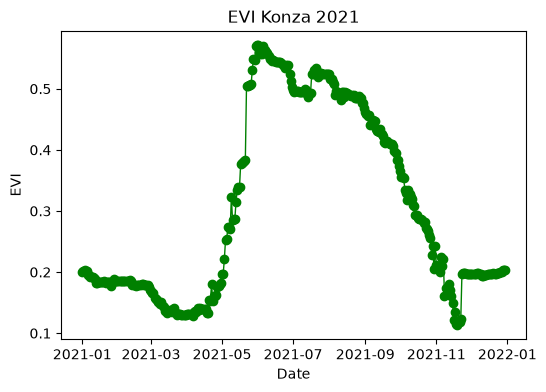

In [9]:
# Create figure to visualize time series
plt.figure(figsize=(6,4))
plt.title('EVI Konza 2021')
plt.plot(df_konza['time'], df_konza['EVI'], linestyle='-', 
         linewidth=1, marker='o', color='green')
plt.xlabel('Date')
plt.ylabel('EVI')
#plt.savefig('evi_figure.png', dpi=300)
plt.show()


## Example 2: Drought index

Drought can be represented by a variety of indices, including soil moisture, potential atmospheric demand, days without measurable precipitation, and indices that combine one or more of these variables. The Evaporative Demand Drought Index (EDDI) is intended to represent the potential for drought (rather than the actual occurrence of drought).

In this exercise we will compare drought conditions for eastern and western Kansas during 2021 and 2022.

Product: [GRIDMET DROUGHT](https://developers.google.com/earth-engine/datasets/catalog/GRIDMET_DROUGHT)


In [10]:
# Define locations
eastern_ks = ee.Geometry.Point([-95.317201, 38.588548]) # Near Ottawa, KS
western_ks = ee.Geometry.Point([-101.721117, 38.517258]) # Near Tribune, KS


In [11]:
# Load EDDI product
gridmet_drought = ee.ImageCollection("GRIDMET/DROUGHT").filterDate('2021-01-01','2022-12-31')
eddi = gridmet_drought.select('eddi14d')


In [12]:
# Get EDDI for points
eastern_eddi = eddi.getRegion(eastern_ks, scale=1).getInfo()
western_eddi = eddi.getRegion(western_ks, scale=1).getInfo()


In [13]:
# Explore output
eastern_eddi[0:3]

[['id', 'longitude', 'latitude', 'time', 'eddi14d'],
 ['20210105',
  -95.31720298383848,
  38.588547875926515,
  1609826400000,
  -0.029999999329447746],
 ['20210110',
  -95.31720298383848,
  38.588547875926515,
  1610258400000,
  -1.1299999952316284]]

In [14]:
# Create dataframe for each point
df_eastern = array_to_df(eastern_eddi)
df_western = array_to_df(western_eddi)

# Display a few rows
df_eastern.head()

# Save data to a comma-separated value file
# df_eastern.to_csv('eddi_14_day.csv', index=False)

,id,longitude,latitude,time,eddi14d
0,20210105,-95.317203,38.588548,2021-01-05 06:00:00,-0.03
1,20210110,-95.317203,38.588548,2021-01-10 06:00:00,-1.13
2,20210115,-95.317203,38.588548,2021-01-15 06:00:00,-0.03
3,20210120,-95.317203,38.588548,2021-01-20 06:00:00,0.39
4,20210125,-95.317203,38.588548,2021-01-25 06:00:00,0.39


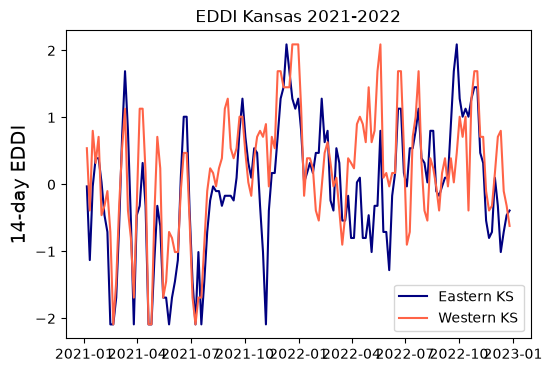

In [15]:
# Create figure to compare EDDI for both points
plt.figure(figsize=(6,4))
plt.title('EDDI Kansas 2021-2022')
plt.plot(df_eastern['time'], df_eastern['eddi14d'], linestyle='-', color='navy', label='Eastern KS')
plt.plot(df_western['time'], df_western['eddi14d'], linestyle='-', color='tomato', label='Western KS')
plt.legend()
plt.ylabel('14-day EDDI', size=14)
plt.show()


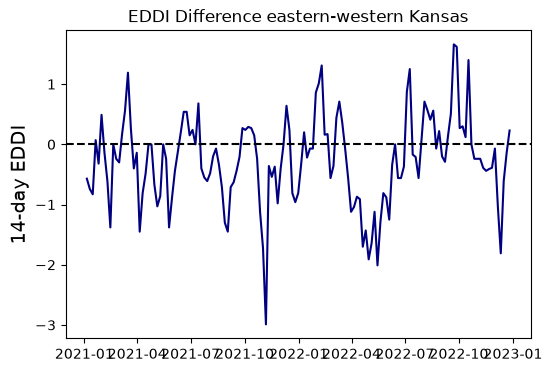

In [16]:
# Compute difference. If negative, that means that drought potential is greater in
# western Kansas

plt.figure(figsize=(6,4))
plt.title('EDDI Difference eastern-western Kansas')
plt.plot(df_eastern['time'], df_eastern['eddi14d']-df_western['eddi14d'], linestyle='-', color='navy')
plt.axhline(0, linestyle='--', color='k')
plt.ylabel('14-day EDDI', size=14)
plt.show()


## Example 3: Irrigated vs rainfed corn vegetation index

In this example we will compare the NDVI of irrigated and rainfed corn fields in western Kansas using the MODIS 250-meter product.

In [17]:
# Define points
data = {'latitude': [38.7640, 38.7628, 38.7787, 38.7642, 38.7162, 38.7783],
        'longitude':[-101.8946, -101.8069, -101.6937, -101.9922, -101.8284, -101.9919],
        'irrigated':[True, True, True, False, False, False]}

df = pd.DataFrame(data)
df.head()


,latitude,longitude,irrigated
0,38.7640,-101.8946,True
1,38.7628,-101.8069,True
2,38.7787,-101.6937,True
3,38.7642,-101.9922,False
4,38.7162,-101.8284,False


In [18]:
# Get product
MOD13Q1 = ee.ImageCollection("MODIS/061/MOD13Q1").filterDate(ee.Date("2022-04-01"),ee.Date("2022-11-15"))


Since in this particular exercise we have multiple locations, one simple solution is to iterate over each point and request the time series of NDVI.

In [19]:
# Iterate over each point and retrieve NDVI
ndvi={}

for k, row in df.iterrows():
    point = ee.Geometry.Point(row['longitude'], row['latitude'])
    result = MOD13Q1.select('NDVI').getRegion(point, 0.01).getInfo()
    result_in_columns = np.transpose(result)
    ndvi[f"field_{k+1}"] = result_in_columns[4][1:]
    dates = result_in_columns[0][1:]
    

In [20]:
# Create Dataframe with the NDVI data for each field
df_ndvi = pd.DataFrame(ndvi,dtype=float)

# Add dates as index
df_ndvi.index = pd.to_datetime(dates, format='%Y_%m_%d')

# Apply conversion factor
df_ndvi = df_ndvi*0.0001

df_ndvi.head()

,field_1,field_2,field_3,field_4,field_5,field_6
2022-04-07,0.1933,0.2024,0.2222,0.2934,0.2032,0.2007
2022-04-23,0.2118,0.2178,0.1972,0.2785,0.2104,0.2107
2022-05-09,0.1824,0.2039,0.2220,0.2328,0.1959,0.1827
2022-05-25,0.2440,0.2056,0.2632,0.2115,0.1943,0.1902
2022-06-10,0.3325,0.2236,0.2235,0.2186,0.2033,0.2054


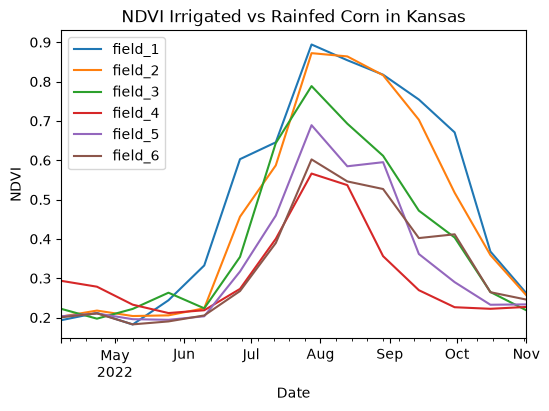

In [21]:
df_ndvi.plot(figsize=(6,4))
plt.title('NDVI Irrigated vs Rainfed Corn in Kansas')
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.show()